# Día 6: Inferencia Estadística

**Business Analytics & Data Science** | EAE Business School | 9 junio 2026

En este notebook vamos a:
1. Calcular intervalos de confianza
2. Realizar t-tests (una y dos muestras)
3. Realizar un test chi-cuadrado
4. Ver un caso significativo y otro NO significativo en datos reales

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
df = pd.read_csv("https://raw.githubusercontent.com/ber2/eae-python/main/data/Houses_Barcelona_samp.csv")
print("Datos cargados:", df.shape)

Datos cargados: (1000, 20)


## Parte 1: Intervalo de confianza

IC 95% para el precio medio.

In [2]:
precios = df["price"].dropna()
n = len(precios)
media = precios.mean()
se = precios.std() / np.sqrt(n)
ic = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
print(f"Media: {media:,.0f}€   (n={n})")
print(f"IC 95%: [{ic[0]:,.0f}€, {ic[1]:,.0f}€]")

Media: 448,640€   (n=998)
IC 95%: [420,781€, 476,499€]


## Parte 2: T-test de una muestra

¿Es el precio medio distinto de 300.000€?

In [3]:
t_stat, p = stats.ttest_1samp(precios, 300000)
print(f"t = {t_stat:.3f},  p = {p:.4g}")
print("Rechazamos H₀: el precio medio difiere de 300k" if p < 0.05 else "No rechazamos H₀")

t = 10.470,  p = 2.077e-24
Rechazamos H₀: el precio medio difiere de 300k


## Parte 3: T-test de dos muestras

¿Los pisos con terraza son más caros? Visualizamos primero.

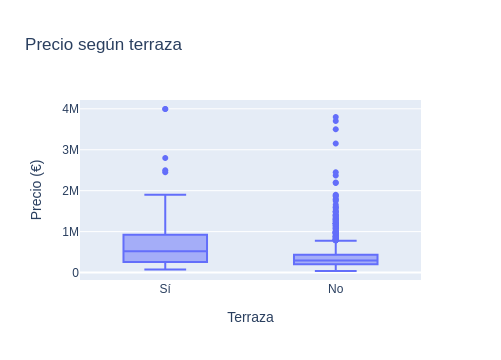

In [4]:
df["Terraza"] = df["terrace"].fillna(0).map({1:"Sí", 0:"No"})
px.box(df, x="Terraza", y="price", title="Precio según terraza",
       labels={"price":"Precio (€)"})

In [5]:
con = df[df["terrace"] == 1]["price"].dropna()
sin = df[df["terrace"].fillna(0) == 0]["price"].dropna()
t_stat, p = stats.ttest_ind(con, sin, equal_var=False)
print(f"Con terraza: {con.mean():,.0f}€ (n={len(con)})")
print(f"Sin terraza: {sin.mean():,.0f}€ (n={len(sin)})")
print(f"t = {t_stat:.3f},  p = {p:.4g}  →", "significativo" if p<0.05 else "no significativo")

Con terraza: 710,332€ (n=149)
Sin terraza: 402,713€ (n=849)
t = 5.567,  p = 1.02e-07  → significativo


## Parte 4: Test chi-cuadrado

¿Hay asociación entre barrio y tipo de propiedad?

In [6]:
tabla = pd.crosstab(df["neighborhood"], df["type"])
chi2, p, dof, esperado = stats.chi2_contingency(tabla)
print(f"χ² = {chi2:.2f},  dof = {dof},  p = {p:.4g}")
print("Hay asociación significativa entre barrio y tipo" if p<0.05 else "Sin asociación significativa")

χ² = 142.20,  dof = 81,  p = 3.152e-05
Hay asociación significativa entre barrio y tipo


## Parte 5: Dos resultados, dos lecciones (Hotel Bookings)

A veces el test **rechaza** H₀ y a veces **no**. Ambos casos son informativos.

In [7]:
dfh = pd.read_csv("https://raw.githubusercontent.com/ber2/eae-python/main/data/hotel_bookings.csv")
print("Reservas:", dfh.shape)
dfh[["hotel","deposit_type","adr","is_canceled"]].head()

Reservas: (1000, 19)


,hotel,deposit_type,adr,is_canceled
0,City Hotel,No Deposit,121.32,0
1,Resort Hotel,Non Refund,120.66,0
2,Resort Hotel,No Deposit,218.36,1
3,City Hotel,Non Refund,54.59,0
4,City Hotel,No Deposit,238.92,0


### Caso A — Cancelación vs tipo de depósito → **significativo**

In [8]:
tab = pd.crosstab(dfh["deposit_type"], dfh["is_canceled"])
tasa = (tab[1] / tab.sum(axis=1)).round(3)
print("Tasa de cancelación por tipo de depósito:")
print(tasa)
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(f"\nχ² = {chi2:.2f},  p = {p:.4g}  →", "significativo" if p<0.05 else "no significativo")

Tasa de cancelación por tipo de depósito:
deposit_type
No Deposit    0.340
Non Refund    0.217
Refundable    0.257
dtype: float64

χ² = 11.68,  p = 0.002904  → significativo


### Caso B — ADR (precio medio diario) ciudad vs resort → **NO significativo**

In [9]:
city = dfh[dfh["hotel"]=="City Hotel"]["adr"].dropna()
resort = dfh[dfh["hotel"]=="Resort Hotel"]["adr"].dropna()
t_stat, p = stats.ttest_ind(city, resort, equal_var=False)
print(f"ADR City:   {city.mean():.2f} (n={len(city)})")
print(f"ADR Resort: {resort.mean():.2f} (n={len(resort)})")
print(f"t = {t_stat:.3f},  p = {p:.4g}  →", "significativo" if p<0.05 else "no significativo")
print("\nNo rechazar H₀ NO demuestra que sean iguales: solo que no hay evidencia suficiente.")

ADR City:   175.17 (n=596)
ADR Resort: 168.38 (n=379)
t = 1.398,  p = 0.1625  → no significativo

No rechazar H₀ NO demuestra que sean iguales: solo que no hay evidencia suficiente.


## Resumen

✅ Intervalos de confianza para la media
✅ T-test de una y de dos muestras
✅ Test chi-cuadrado para variables categóricas
✅ Un caso significativo (depósito→cancelación) y uno no significativo (ADR)

**Clave**: "no significativo" ≠ "no hay efecto". Reportad siempre p-value y magnitud.